# Curso de Métodos Numéricos
# Tarea 6

| Descripción:                         | Fechas                   |
|--------------------------------------|--------------------------|
| Fecha de publicación del documento:  | **Octubre 2, 2026**   |
| Fecha límite de entrega de la tarea: | **Octubre 11, 2026**  |

## Indicaciones


Este notebook debe ser un reporte de la tarea, por lo cual:

- Para los ejercicios teóricos puede escribir la respuesta en una celda Markdown o
  insertar una imagen con la respuesta si se ve claran las palabras.
- Para los ejercicios prácticos hay que escribir el código de las funciones que implementan
  los algoritmos y los casos de prueba en C o C++. Ejecute las celdas para que queden registrados
  los resultados.
- Cuando se dice que una función de C tiene que devolver una serie de valores,
  puede definir algunos de los argumentos de la función como apuntadores o indicar que
  se pasan los valores de una variable por referencia, para que puedan ser modificados
  dentro de la función. También podría definir una estructura de datos, pero tome en cuenta
  que para cada algoritmo tendría que definir una estructura de datos diferente. La elección
  de como define las entradas y salidas de una función es libre.
- En caso que se pida generar una gráfica, puede exportar los datos que se necesitan a
  un archivo CSV, Excel o Json, y en usar otro Notebook para leer los datos y generar la gráfica
  usando Julia, Python o R.
- Hay que subir al Classroom el notebook y los archivos necesarios para compilar y ejecutar los programas en un archivo Zip.
- No agregue al Zip los programas ejecutables.
- También hay que exportar el notebook a PDF y agregarlo al Classroom para poner anotaciones
  y dar la retroalimentación correspondiente de la tarea.


---

## Ejercicio 1 (5 puntos)

Ajuste un polinomio de grado $n$ a un conjunto de puntos ${(x_i, y_i)}_{i=1}^m$ usando el método de mínimos cuadrados lineales.
Ver la sección "Ajuste de modelos polinomiales" de las diapositivas de la Clase 14.

1. Programe la función que devuelve la matriz de diseño $\mathbf{X}$ del problema:

**Entrada:**
- El arreglo con las abscisas $[x_1, x_2, ..., x_m]$.
- El número de puntos $m$.
- El grado del polinomio $n$.

**Salida:**
- La matriz de diseño $\mathbf{X}$ de tamaño $m \times (n+1)$.

**Procedimiento:**
- Reserva memoria para el arreglo y llena la matriz.

$$\mathbf{X} = \begin{bmatrix}
x_1^n & \cdots & x_1 & 1 \\
x_2^n & \cdots & x_2 & 1 \\
\vdots &  & \vdots  & \vdots \\
x_m^n & \cdots &  x_m & 1
\end{bmatrix}.$$

2. Programe la función que calcula la solución del problema de mínimos cuadrados

**Entrada:**
- La matriz de diseño $\mathbf{X}$.
- El arreglo con las ordenadas $[y_1, y_2, ..., y_m]$.
- El número de puntos $m$.
- El grado del polinomio $n$.

**Salida:**
- Los coeficientes $c_0, c_1, ..., c_n$ del polinomio $p(x) = \sum_{j=0}^n c_j x^j$.

**Procedimiento:**
- Calcula la matriz y el vector independiente del sistema de ecuaciones que
  tiene que resolver para calcular los coeficientes.
- Resuelve el sistema para obtener los coeficientes del polinomio.

3. Programe la función para probar el método de mínimos cuadrados:

**Entrada:**
- El nombre del archivo con los datos
- El grado $n$ del polinomio que se quiere ajustar

**Salida:**
- Los coeficientes del polinomio almacenados en un archivo.

**Procedimiento:**
- La función lee el archivo de datos y crea los arreglos de las abscisas $\mathbf{x}$ y las ordenadas $\mathbf{y}$ de tamaño $m$.
- Crea la matriz de diseño $\mathbf{X}$ y calcula los coeficientes $\mathbf{c}$ del polinomio.
- Imprima el grado del polinomio $n$, el arreglo $\mathbf{c}$ y el error cuadrático medio:

$$ RMSE = \sqrt{\frac{(\mathbf{X}\mathbf{c} - \mathbf{y})^\top(\mathbf{X}\mathbf{c} - \mathbf{y})}{m}}.$$

- Grabe los valores de los coeficientes en un archivo que pueda leer en el notebook para generar la gráfica del polinomio junto con los puntos.

En python se puede usar la función `numpy.polyval(coeff, x)` en la que
se proporciona los coeficientes del polinomio y el punto en el que se evalúa el polinomio.

4. Use el archivo `puntos2D.bin` dentro de `datosTarea06.zip` y use la función del punto anterior para calcular los coeficientes de los polinomios de grado $n=2, 4, 6$ y muestre las gráficas de los polinomios y los datos para observar el ajuste.


Matplotlib is building the font cache; this may take a moment.


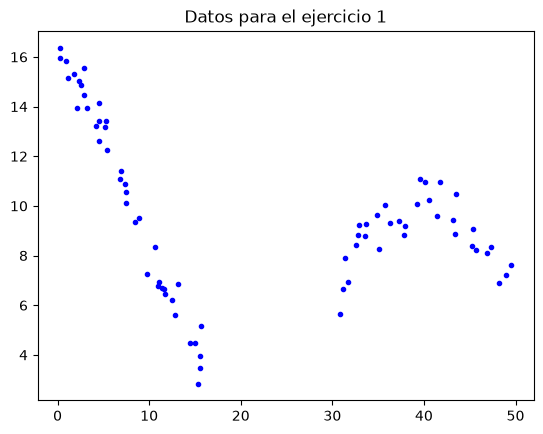

In [ ]:
import numpy as np
import struct
import matplotlib.pyplot as plt


def readMatrixBinFile(fullname):
    with open(fullname, 'rb') as f:
        rows = struct.unpack('q', f.read(8))[0]
        cols = struct.unpack('q', f.read(8))[0]
        arr1 = np.fromfile(f, dtype=np.float64)
        return arr1.reshape(rows, cols)

XY = readMatrixBinFile('datosTarea06/puntos2D.bin')
plt.plot(XY[:,0], XY[:,1], 'b.')
plt.title('Datos para el ejercicio 1')
plt.show()

### Solución:

In [ ]:
# Función para leer un archivo binario de un arreglo 1D
def readCoefBinFile(fullname):
    with open(fullname, 'rb') as f:
        size = struct.unpack('q', f.read(8))[0]
        arr1 = np.fromfile(f, dtype=np.float64)
        return arr1

In [ ]:
# Coeficientes de un polinomio de grado 2
# El primer elemento corresponde al término x^2
# El último elemento corresponde al término independiente
coef_2 = readCoefBinFile('datosTarea06/coeficientes_polinomio_grado_2.bin')
# Invertimos el orden de los coeficientes
coef_2_inverted = coef_2[::-1]
# Crear el objeto polinomio
# Dados el arreglo de coeficientes: [c0, c1, c2] -> c0 + c1*x + c2*x^2 es el polinomio obtenido
p_grado_2 = np.polynomial.polynomial.Polynomial(coef_2_inverted)

# Coeficientes de un polinomio de grado 4
coef_4 = readCoefBinFile('datosTarea06/coeficientes_polinomio_grado_4.bin')
coef_4_inverted = coef_4[::-1]
p_grado_4 = np.polynomial.polynomial.Polynomial(coef_4_inverted)

# coeficientes de un polinomio de grado 6
coef_6 = readCoefBinFile('datosTarea06/coeficientes_polinomio_grado_6.bin')
coef_6_inverted = coef_6[::-1]
p_grado_6 = np.polynomial.polynomial.Polynomial(coef_6_inverted)

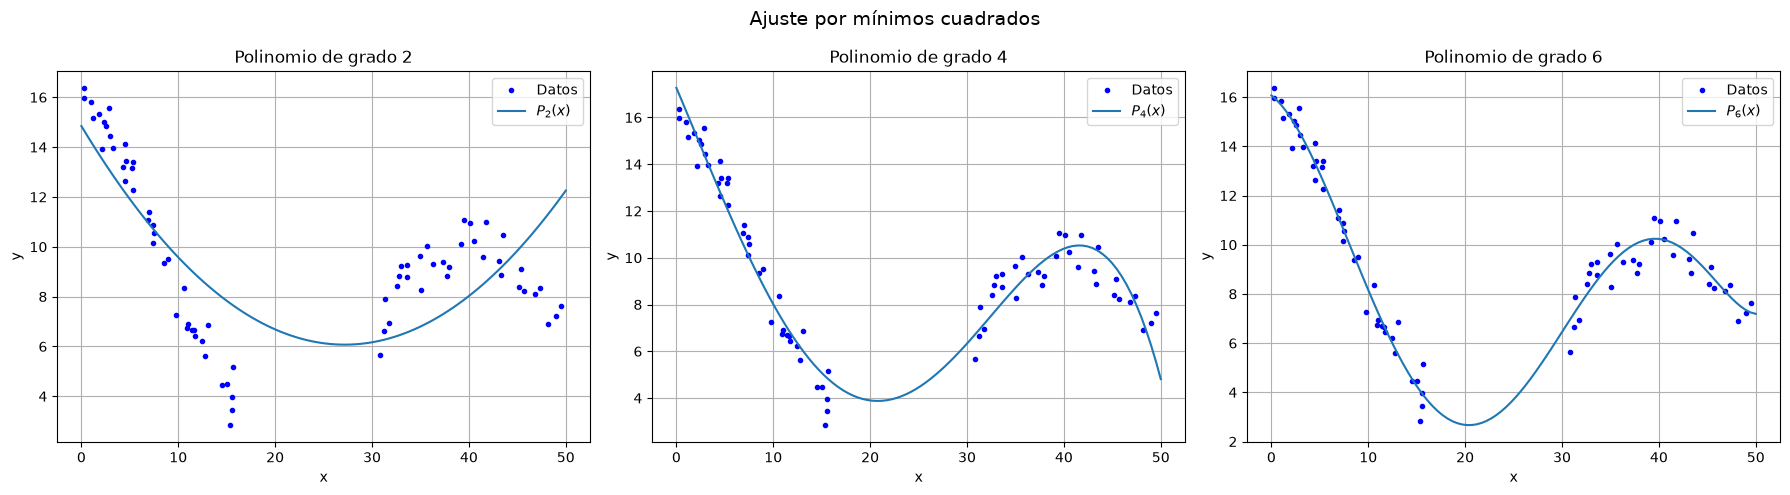

In [27]:
# Puntos a evaluar en los polinomios
X = np.linspace(0, 50, 100)

# Crear subplots de 1 fila y 3 columnas
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Polinomio de grado 2
axs[0].plot(XY[:, 0], XY[:, 1], 'b.', label='Datos')
axs[0].plot(X, p_grado_2(X), label=r'$P_2(x)$')
axs[0].set_title('Polinomio de grado 2')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].legend()
axs[0].grid(True)

# Polinomio de grado 4
axs[1].plot(XY[:, 0], XY[:, 1], 'b.', label='Datos')
axs[1].plot(X, p_grado_4(X), label=r'$P_4(x)$')
axs[1].set_title('Polinomio de grado 4')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].legend()
axs[1].grid(True)

# Polinomio de grado 6
axs[2].plot(XY[:, 0], XY[:, 1], 'b.', label='Datos')
axs[2].plot(X, p_grado_6(X), label=r'$P_6(x)$')
axs[2].set_title('Polinomio de grado 6')
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')
axs[2].legend()
axs[2].grid(True)

# Título general
fig.suptitle('Ajuste por mínimos cuadrados', fontsize=14)

plt.tight_layout()
plt.show()

```



```
----

## Ejercicio 2 (5 puntos)

Considere el problema de ajustar una circunferencia a un conjunto
de puntos $\{(x_k, y_k)\}_{k=1}^m$.

Se propone usar el siguiente modelo que involucra a las coordenadas
$(c_1, c_2)$ del centro de la circunferencia y su radio $c_3$:
$$x_k = c_1 + c_3 \cos \theta_k + \epsilon_k$$
$$y_k = c_2 + c_3 \cos \theta_k + \eta_k$$

donde $\theta_k$ es el ángulo del vector $(x_k - c_1, y_k - c_2)$.

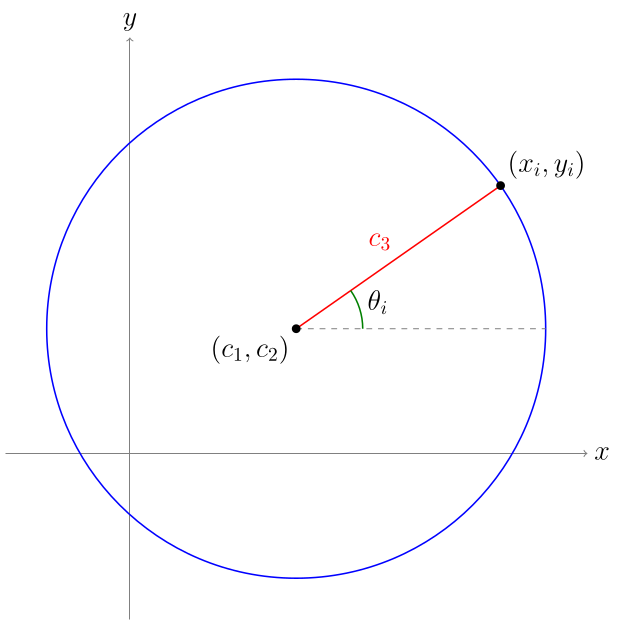

El problema es que $(c_1, c_2)$ es desconocido, por lo que no se puede calcular $\theta_k$.

Por esta razón, se propone dar un punto inicial $(\bar{x}, \bar{y})$, el cual
es el centroide de los datos:

$$\bar{x} = \frac{1}{m} \sum_{i=1}^m x_i, \quad  \bar{y} = \frac{1}{m} \sum_{i=1}^m y_i.$$

Con este punto se calculan los ángulos $\theta_k$ de los vectores $(x_k - \bar{x}, y_k - \bar{x})$, se contruye la matriz de diseño $\mathbf{X}$ y el vector de los datos $\mathbf{z}$ que debe predecir el modelo y se plantea el problema de mínimos cuadrados para calcular el vector de parámetros $\mathbf{c}=(c_1, c_2, c_3)^\top$:

$$\min_c E = (\mathbf{X}\mathbf{c} - \mathbf{z})^\top(\mathbf{X}\mathbf{c} - \mathbf{z}). $$

Si se tienen datos como los que muestran en la siguiente figura, el centroide no
es una buena aproximación  del centro de la circunferencia, por ello conviene repetir el proceso usando $\bar{x} = c_1$ y $\bar{y} = c_2$, es decir, usando la solución obtenida para tener un mejor cálculo de los ángulos $\theta_k$.

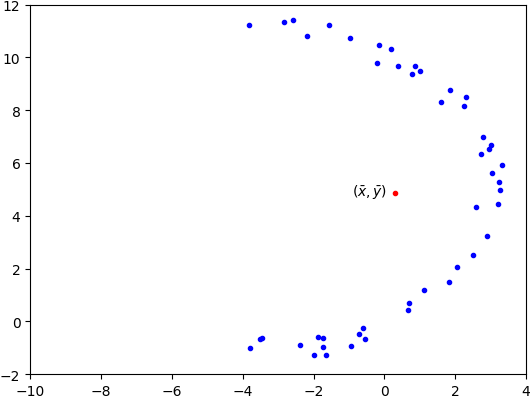

Así se puede continuar repitiendo el procedimiento hasta que no haya un cambio significativo en el centro de la circunferencia de una iteración a la siguiente.


1. Programe la función que devuelve la matriz de diseño $\mathbf{X}$ del problema:

**Entrada:**
- El arreglo con las abscisas $[x_1, x_2, ..., x_m]$ y las ordenadas $[y_1, y_2, ..., y_m]$.
- El número de puntos $m$.
- El punto $(\bar{x}, \bar{y})$.

**Salida:**
- La matriz de diseño $\mathbf{X}$.

**Procedimiento:**
- Reserva memoria para el arreglo y llena la matriz calculando los
  ángulos $\theta_k$ usando la función $atan2(y_i - \bar{y}, x_i-\bar{x})$
  o una función similar.


2. Programe la función que calcula la solución del problema de mínimos cuadrados

**Entrada:**
- La matriz de diseño $\mathbf{X}$.
- El arreglo $\mathbf{z}$ que debe predecir el modelo.

**Salida:**
- Los parámetros $c_1, c_2, c_3$ del modelo.

**Procedimiento:**
- Calcula la matriz y el vector independiente del sistema de ecuaciones que
  tiene que resolver para calcular los parámetros.
- Resuelve el sistema para obtener los parámetros.

3. Programe la función para que prueba el método de mínimos cuadrados:

**Entrada:**
- El nombre del archivo con los datos
- El número $N$ de iteraciones máximas
- Una tolerancia $\tau>0$ para terminar las iteraciones.

**Salida:**
- Los paramétros de la circunferencia.

**Procedimiento:**
- La función lee el archivo de datos y crea los arreglos que necesita para usar
  las funciones anteriores. En particular tiene que crear el arreglo $\mathbf{z}$
  que tiene los datos que debe predicir el modelo.
- Inicializa el punto $(\bar{x}, \bar{y})$ con los valores del centroide
  de los puntos proporcionados y empieza las iteraciones.
- En cada iteración, usa la función del primer inciso para construir la matriz
  de diseño $\mathbf{X}$ usando el punto $(\bar{x}, \bar{y})$.
  Luego usa la función del segundo inciso para resolver el problema
  de mímimos cuadrados. Si $\|(\bar{x}-c_1, \bar{y}-c_2)\|<\tau$, hay que terminar
  de iterar.
- En cada iteración imprima $c_1, c_2, c_3$  y el valor
  
$$ RMSE = \sqrt{\frac{(\mathbf{X}\mathbf{c} - \mathbf{z})^\top(\mathbf{X}\mathbf{z} - \mathbf{y})}{m}}.$$

4. Pruebe la función anterior usando los archivos `circunferencia1.bin` y
   `circunferencia2.bin` que están en `datosTarea06.zip`.

- Use $N=30$ y $\tau = 0.01$.
- Use el resultado para generar una gráfica que muestre los puntos y
  la circunferencia obtenida.

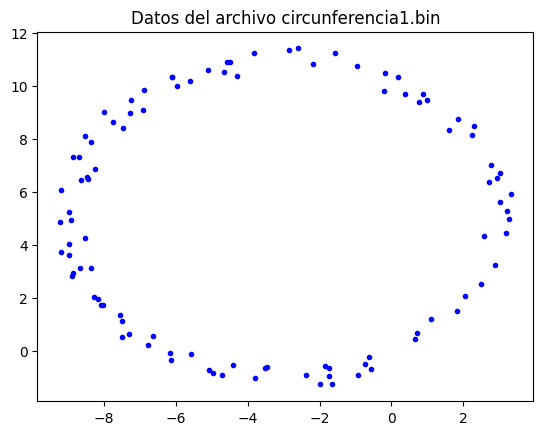

In [ ]:
import numpy as np
import struct
import matplotlib.pyplot as plt

def readMatrixBinFile(fullname):
    with open(fullname, 'rb') as f:
        rows = struct.unpack('q', f.read(8))[0]
        cols = struct.unpack('q', f.read(8))[0]
        arr1 = np.fromfile(f, dtype=np.float64)
        return arr1.reshape(rows, cols)

XY = readMatrixBinFile('datosTarea06/circunferencia1.bin')
plt.plot(XY[:,0], XY[:,1], 'b.')
plt.title('Datos del archivo circunferencia1.bin')
plt.show()

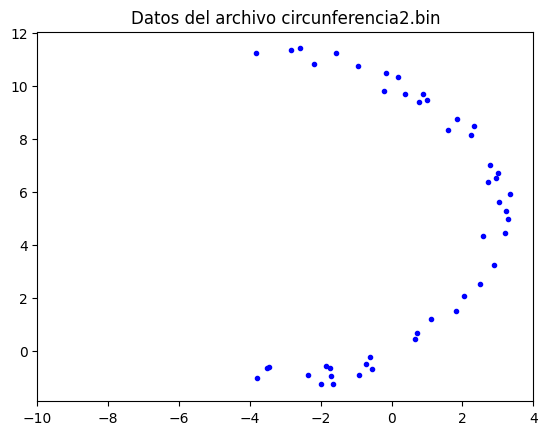

In [10]:
XY = readMatrixBinFile('datosTarea06/circunferencia2.bin')
plt.plot(XY[:,0], XY[:,1], 'b.')
plt.xlim(-10,4)
plt.title('Datos del archivo circunferencia2.bin')
plt.show()

### Solución:

```



```
----